# <font style="color:black">Basic Image Enhancement Using Mathematical Operations</font>
Covered:
* Arithmetic Operations like addition, multiplication
* Thresholding & Masking
* Bitwise Operations like OR, AND, XOR

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from zipfile import ZipFile
from urllib.request import urlretrieve
from IPython.display import Image
%matplotlib inline

##  <font style="color:black">Download Assets</font>

In [ ]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    urlretrieve(url, save_path)

    try:
        with ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [ ]:
URL = r"https://www.dropbox.com/s/0oe92zziik5mwhf/opencv_bootcamp_assets_NB4.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), "opencv_bootcamp_assets_NB4.zip")

if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

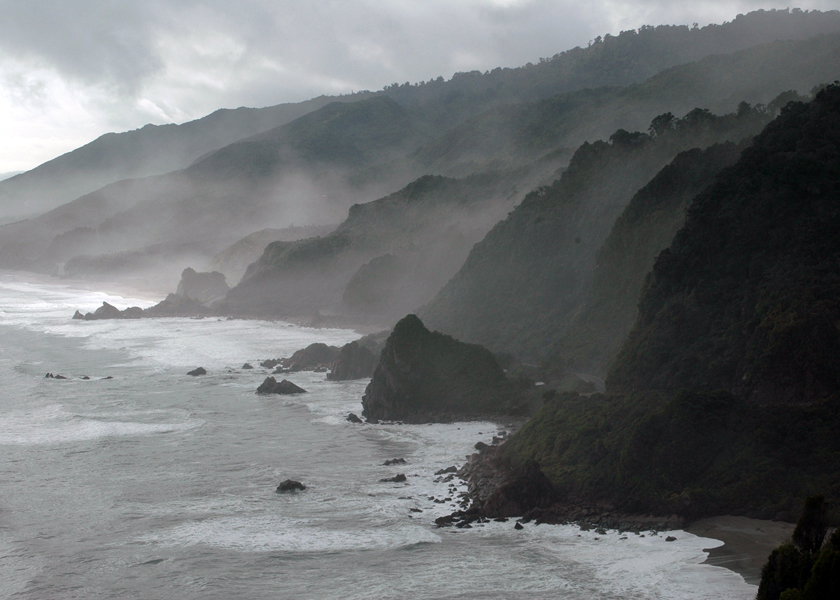

In [ ]:
img_bgr = cv2.imread("New_Zealand_Coast.jpg", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
Image(filename="New_Zealand_Coast.jpg")

## Addition or Brightness


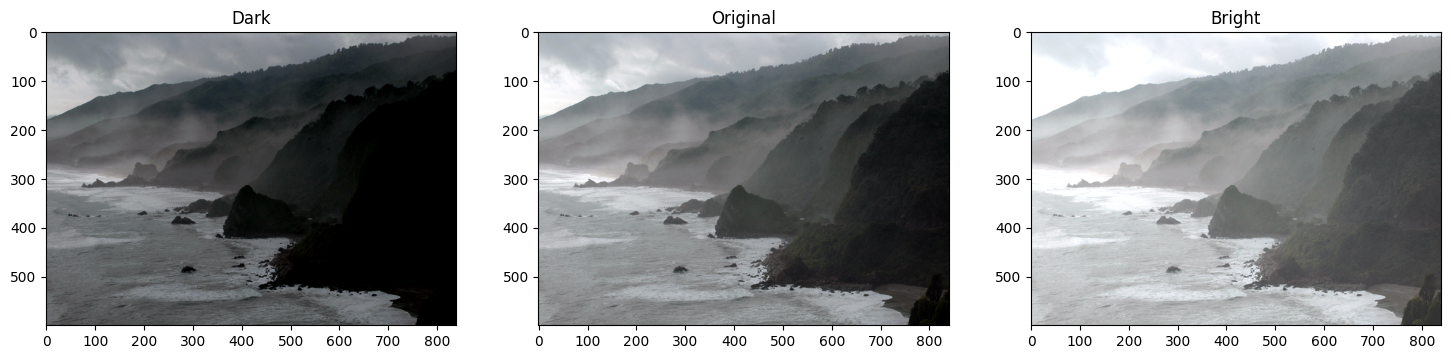

In [ ]:
matrix = np.ones(img_rgb.shape, dtype="uint8") * 50
img_rgb_brighter = cv2.add(img_rgb, matrix)
img_rgb_darker   = cv2.subtract(img_rgb, matrix)
plt.figure(figsize=[18, 5])
plt.subplot(131); plt.imshow(img_rgb_darker);  plt.title("Dark");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter);plt.title("Bright");

## Multiplication or Contrast


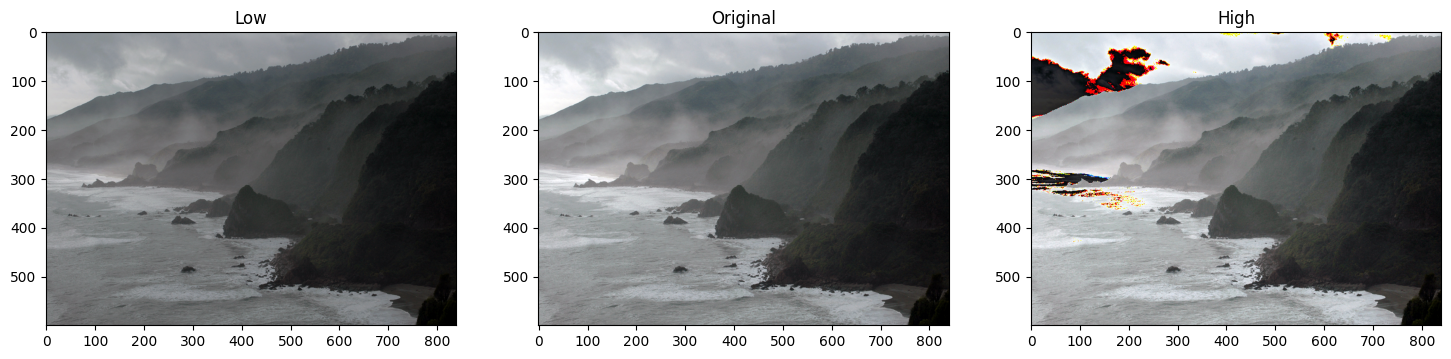

In [ ]:
matrix_low_contrast = np.ones(img_rgb.shape) * 0.8
matrix_high_contast = np.ones(img_rgb.shape) * 1.2
img_rgb_darker   = np.uint8(cv2.multiply(np.float64(img_rgb), matrix_low_contrast))
img_rgb_brighter = np.uint8(cv2.multiply(np.float64(img_rgb), matrix_high_contast))
plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_darker);  plt.title("Low");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter);plt.title("High");

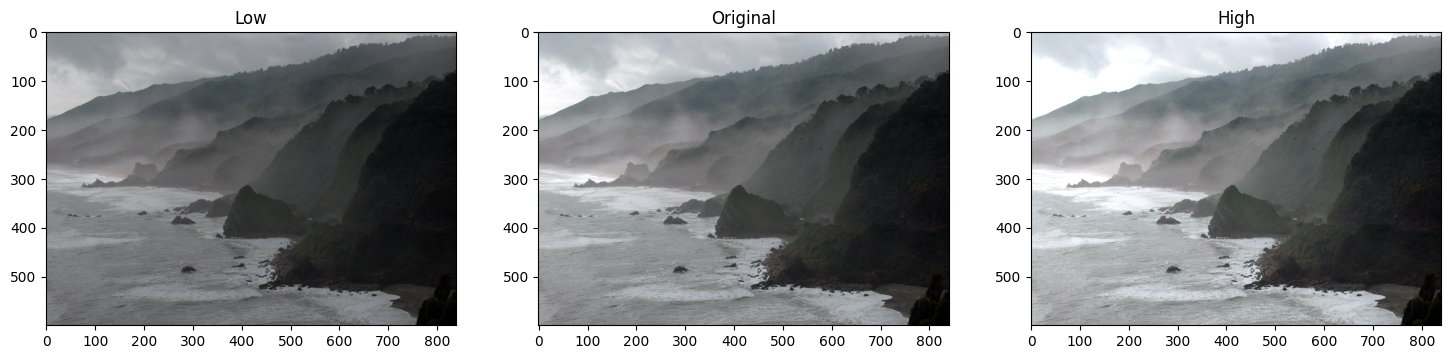

In [ ]:
matrix_low_contrast = np.ones(img_rgb.shape) * 0.8
matrix_high_contast = np.ones(img_rgb.shape) * 1.2
img_rgb_lower  = np.uint8(cv2.multiply(np.float64(img_rgb), matrix_low_contrast))
img_rgb_higher = np.uint8(np.clip(cv2.multiply(np.float64(img_rgb), matrix_high_contast), 0, 255))# used np.clip
plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_lower); plt.title("Low");
plt.subplot(132); plt.imshow(img_rgb);       plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_higher);plt.title("High");

## Image Thresholding


(572, 800)


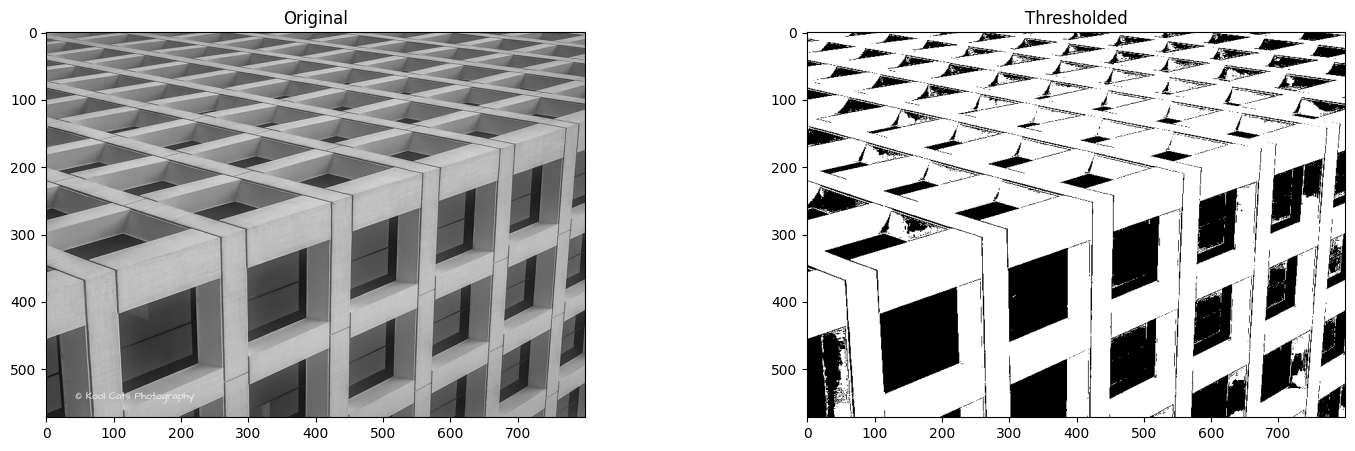

In [ ]:
img_read = cv2.imread("building-windows.jpg", cv2.IMREAD_GRAYSCALE)
retval, img_thresh = cv2.threshold(img_read, 100, 255, cv2.THRESH_BINARY)
plt.figure(figsize=[18, 5])
plt.subplot(121);plt.imshow(img_read, cmap="gray");  plt.title("Original")
plt.subplot(122);plt.imshow(img_thresh, cmap="gray");plt.title("Thresholded")
print(img_thresh.shape)

## Sheet Music Reader

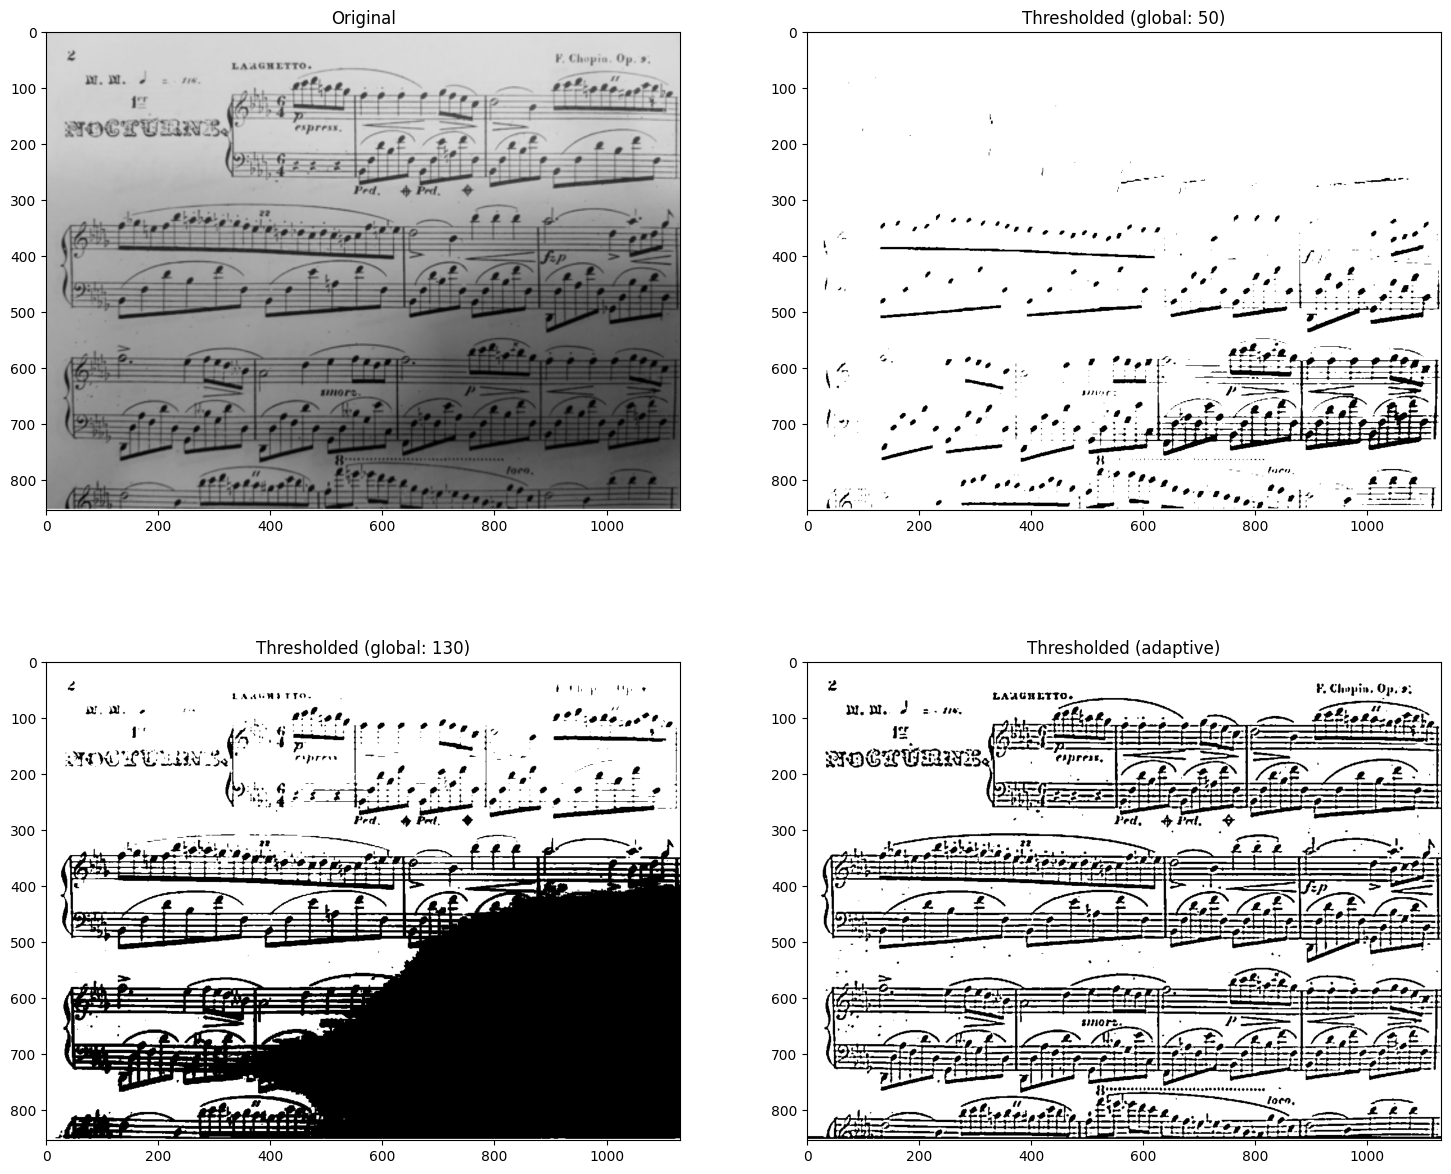

In [ ]:
# Read
img_read = cv2.imread("Piano_Sheet_Music.png", cv2.IMREAD_GRAYSCALE)
# global thresholding
retval, img_thresh_gbl_1 = cv2.threshold(img_read, 50, 255, cv2.THRESH_BINARY)
retval, img_thresh_gbl_2 = cv2.threshold(img_read, 130, 255, cv2.THRESH_BINARY)
# adaptive thresholding
img_thresh_adp = cv2.adaptiveThreshold(img_read, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 7)

plt.figure(figsize=[18,15])
plt.subplot(221); plt.imshow(img_read,        cmap="gray");  plt.title("Original");
plt.subplot(222); plt.imshow(img_thresh_gbl_1,cmap="gray");  plt.title("Thresholded (global: 50)");
plt.subplot(223); plt.imshow(img_thresh_gbl_2,cmap="gray");  plt.title("Thresholded (global: 130)");
plt.subplot(224); plt.imshow(img_thresh_adp,  cmap="gray");  plt.title("Thresholded (adaptive)");

## Bitwise Operations

(200, 499)


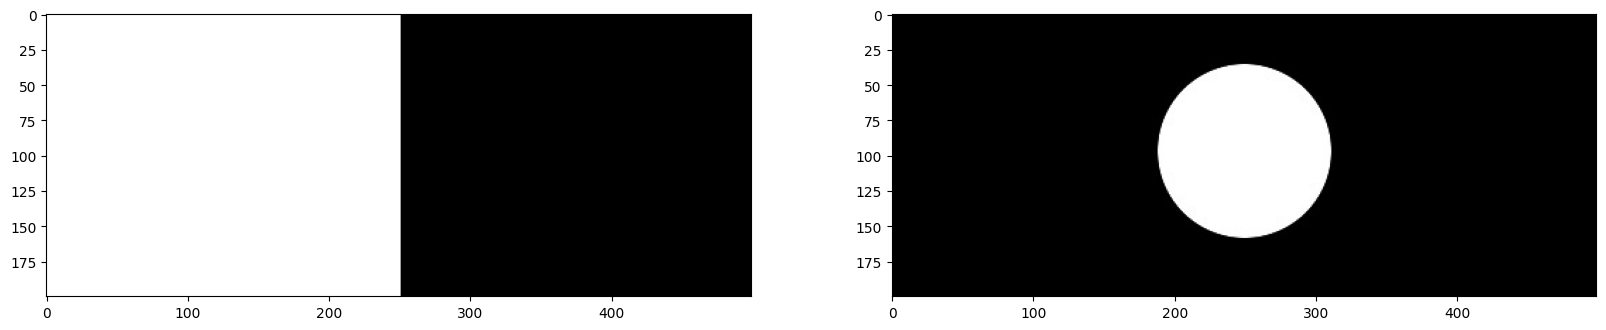

In [ ]:
img_rec = cv2.imread("rectangle.jpg", cv2.IMREAD_GRAYSCALE)
img_cir = cv2.imread("circle.jpg", cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=[20, 5])
plt.subplot(121);plt.imshow(img_rec, cmap="gray")
plt.subplot(122);plt.imshow(img_cir, cmap="gray")
print(img_rec.shape)

### Bitwise AND Operator

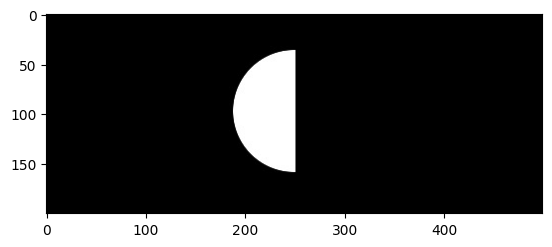

In [ ]:
result = cv2.bitwise_and(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray")

###Bitwise OR Operator

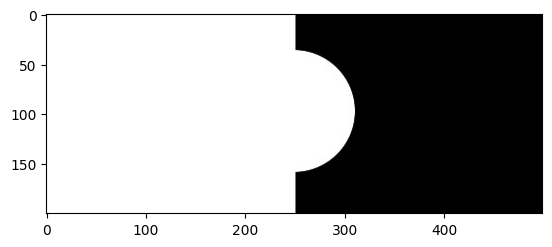

In [ ]:
result = cv2.bitwise_or(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray")

### Bitwise XOR Operator

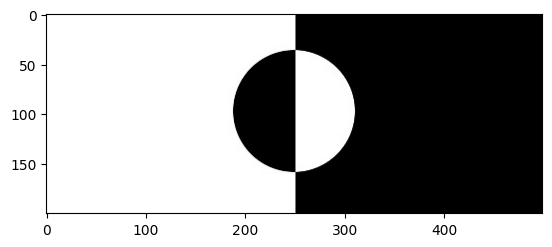

In [ ]:
result = cv2.bitwise_xor(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray")

## Application: Logo Manipulation

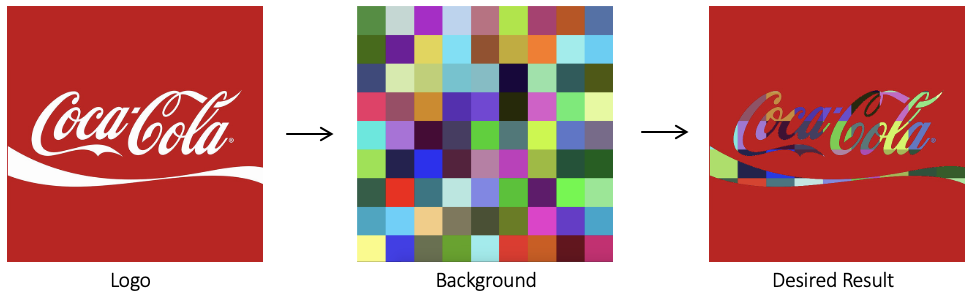

In [ ]:
Image(filename='Logo_Manipulation.png')

(700, 700, 3)
(700, 700, 3)
(700, 700)


True

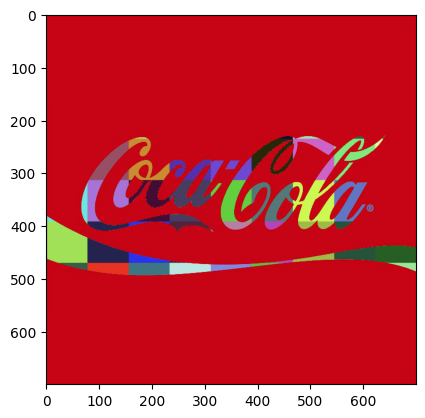

In [ ]:
# Read Foreground image
img_bgr = cv2.imread("coca-cola-logo.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
print(img_rgb.shape)
logo_h = img_rgb.shape[0]
logo_w = img_rgb.shape[1]

# Read Background image
# Read
img_background_bgr = cv2.imread("checkerboard_color.png")
img_background_rgb = cv2.cvtColor(img_background_bgr, cv2.COLOR_BGR2RGB)

# Resize
img_background_rgb = cv2.resize(img_background_rgb, (logo_w, logo_h), interpolation=cv2.INTER_AREA)

plt.imshow(img_background_rgb)
print(img_background_rgb.shape)

# Create Mask for original Image
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
retval, img_mask = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
plt.imshow(img_mask, cmap="gray")
print(img_mask.shape)

# Invert the Mask
img_mask_inv = cv2.bitwise_not(img_mask)
plt.imshow(img_mask_inv, cmap="gray")

# Apply background on the Mask
img_background = cv2.bitwise_and(img_background_rgb, img_background_rgb, mask=img_mask)
plt.imshow(img_background)

# Isolate foreground from image
img_foreground = cv2.bitwise_and(img_rgb, img_rgb, mask=img_mask_inv)
plt.imshow(img_foreground)

# Merge Foreground and Background
# Add the two previous results obtain the final result
result = cv2.add(img_background, img_foreground)
plt.imshow(result)
cv2.imwrite("logo_final.png", result[:, :, ::-1])